In [1]:
import torch
from torch import nn

torch.__version__

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


'2.13.0+cpu'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"didnit find one {image_path} ,creating...")
    image_path.mkdir(parents=True,exist_ok=True)

    with open(data_path/"pizza_steak_sushi.zip","wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("downloading data ...")
        f.write(request.content)

    with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zipfile:
        zipfile.extractall(image_path)

data\pizza_steak_sushi directory exists.


In [4]:
import os
def walk_dir(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} image in '{dirpath}''.")

In [5]:
walk_dir(image_path)

There are 2 directories and 0 image in 'data\pizza_steak_sushi''.
There are 3 directories and 0 image in 'data\pizza_steak_sushi\test''.
There are 0 directories and 25 image in 'data\pizza_steak_sushi\test\pizza''.
There are 0 directories and 19 image in 'data\pizza_steak_sushi\test\steak''.
There are 0 directories and 31 image in 'data\pizza_steak_sushi\test\sushi''.
There are 3 directories and 0 image in 'data\pizza_steak_sushi\train''.
There are 0 directories and 78 image in 'data\pizza_steak_sushi\train\pizza''.
There are 0 directories and 75 image in 'data\pizza_steak_sushi\train\steak''.
There are 0 directories and 72 image in 'data\pizza_steak_sushi\train\sushi''.


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

Random image path: data\pizza_steak_sushi\test\sushi\2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


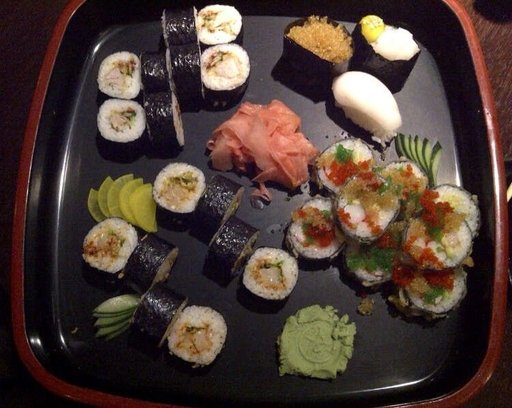

In [7]:
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

image name : sushi,image shape : (408, 512, 3)


(np.float64(-0.5), np.float64(511.5), np.float64(407.5), np.float64(-0.5))

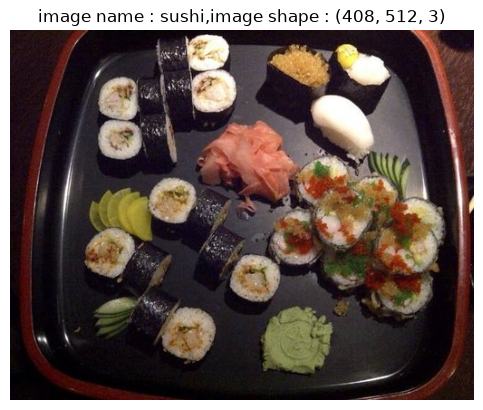

In [8]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)
plt.imshow(img_as_array)
print(f"image name : {image_class},image shape : {img_as_array.shape}")
plt.title(f"image name : {image_class},image shape : {img_as_array.shape}")
plt.axis(False)

In [9]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [10]:
data_tranform = v2.Compose([
    v2.Resize((64,64)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale=True)

])

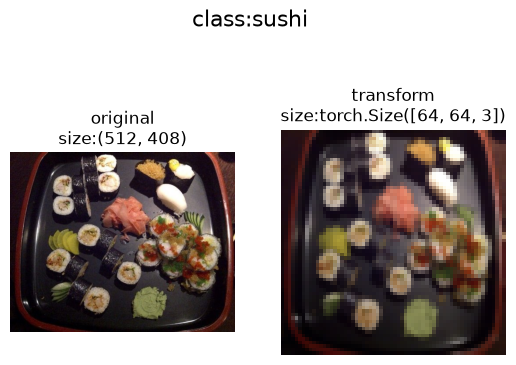

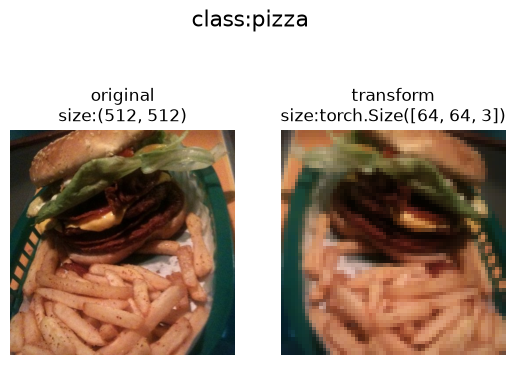

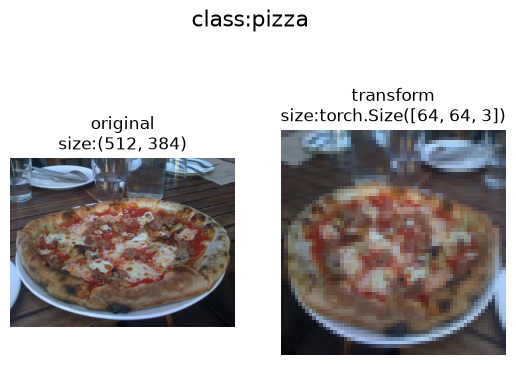

In [11]:
def plot_transforms_image(image_path,transform,n=3,seed=42):
    random.seed(seed)
    random_image_path=random.sample(image_path,k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"original\nsize:{f.size}")
            ax[0].axis("off")
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"transform\nsize:{transformed_image.shape}")
            ax[1].axis("off")
           
            fig.suptitle(f"class:{image_path.parent.stem}",fontsize=16)

plot_transforms_image(image_path_list,transform=data_tranform)

In [12]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_tranform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_tranform)

print(f"train data :\n{train_data}\n Test data :\n {test_data}")

train data :
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
                 Resize(size=[64, 64], interpolation=bilinear, antialias=True)
                 RandomHorizontalFlip(p=0.5)
                 ToImage()
                 ToDtype(scale=True)
           )
 Test data :
 Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
                 Resize(size=[64, 64], interpolation=bilinear, antialias=True)
                 RandomHorizontalFlip(p=0.5)
                 ToImage()
                 ToDtype(scale=True)
           )


In [13]:
class_name=train_data.classes
class_name

['pizza', 'steak', 'sushi']

In [14]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [15]:
len(train_data),len(test_data)

(225, 75)

In [16]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
Image([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
        [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
        [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
        ...,
        [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
        [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
        [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

       [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
        [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
        [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
        ...,
        [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
        [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
        [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

       [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
        [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
        [0.0902, 0.0902, 0.0902,  ..., 0.0157, 0.0157, 0.019

Original shape:torch.Size([3, 64, 64])
Image permute shape :torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

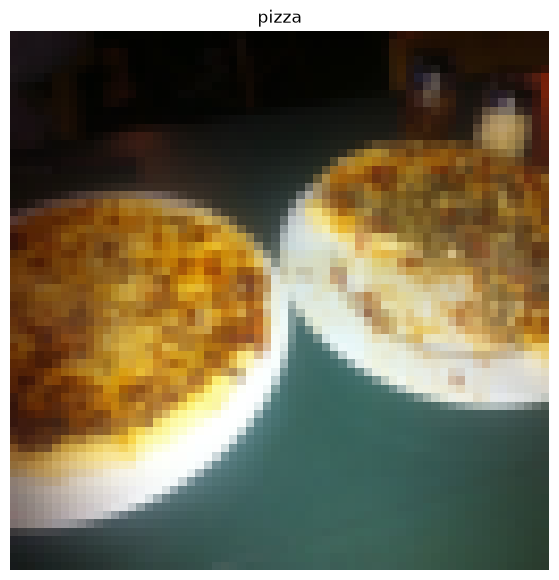

In [17]:
img_permute = img.permute(1,2,0)
print(f"Original shape:{img.shape}")
print(f"Image permute shape :{img_permute.shape}")

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_name[label])

In [18]:
import os
os.cpu_count()

8

In [19]:
from torch.utils.data import DataLoader
train_dataloader= DataLoader(dataset=train_data,
                             batch_size=32,
                             num_workers=1,
                             shuffle=False)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,num_workers=1,shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2a3a98db230>,
 <torch.utils.data.dataloader.DataLoader at 0x2a3aacbdbd0>)

In [20]:
len(train_dataloader),len(test_dataloader)

(8, 3)

In [21]:
img, label =next(iter(train_dataloader))
img.shape,label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [22]:
import os 
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

In [23]:
target_directory = train_dir
class_name_found = sorted([entry.name for entry in list(os.scandir(image_path/"train"))])
target_directory,class_name_found

(WindowsPath('data/pizza_steak_sushi/train'), ['pizza', 'steak', 'sushi'])

In [24]:
target_directory.is_dir()

True

In [25]:
def find_classes(directory:str)-> Tuple[List[str],Dict[str,int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"could not fing{directory}")

    class_to_idx = {class_name:i for i ,class_name in enumerate(classes)}
    return classes,class_to_idx


In [26]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [27]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):

    def __init__(self,tar_dir:str,transforms=None)->None:
        self.path = list(pathlib.Path(tar_dir).glob("*/*.jpg"))
        self.transform=transforms
        self.classes,self.class_to_idx = find_classes(tar_dir)

    def load_image(self,index:int)->Image.Image:
        image_path = self.path[index]
        return Image.open(image_path)

    def __len__(self)->int:
        return len(self.path)

    def __getitem__(self, index:int)->Tuple[torch.Tensor,int]:
        img = self.load_image(index)
        class_name = self.path[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img),class_idx
        else:
            return img , class_idx


In [28]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transformers = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])


In [29]:
train_data_custom = ImageFolderCustom(tar_dir=train_dir, 
                                      transforms=train_transforms)
test_data_custom = ImageFolderCustom(tar_dir=test_dir,
                                     transforms=test_transformers)

train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x2a3a9a041a0>,
 <__main__.ImageFolderCustom at 0x2a3aacbefd0>)

In [30]:
len(train_data_custom),len(test_data_custom)

(225, 75)

In [31]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [32]:
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == test_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


In [33]:
def display_ramdom_images(dataset : torch.utils.data.Dataset,
                          classes : List[str] = None,
                          n : int = 10,
                          display_shape : bool = True,
                          seed : int = None):
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purpose n shouldnit be more than 10")

    if seed :
        random.seed(seed)

    random_sample_idx = random.sample(range(len(dataset)),k=n)

    plt.figure(figsize=(16,8))

    for i ,targ_sample in enumerate(random_sample_idx):
        targ_image, targ_label = dataset[targ_sample][0],dataset[targ_sample][1]
        targ_image_adjust = targ_image.permute(1,2,0)

        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"classes : {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)



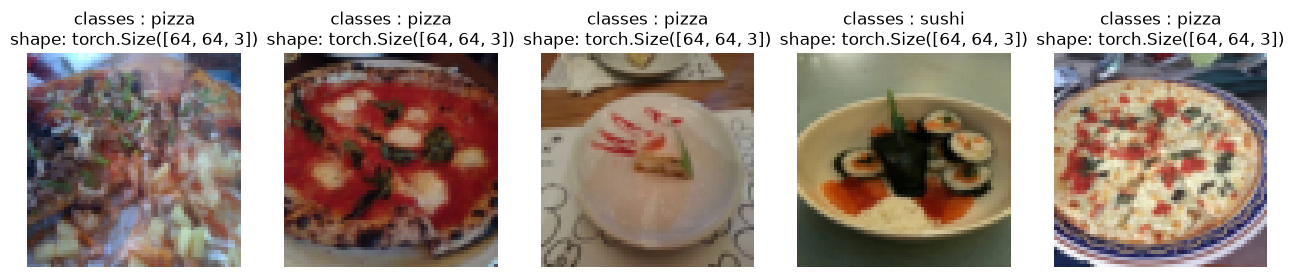

In [34]:
display_ramdom_images(train_data,
                      n=5,
                      classes=class_name,
                      seed=None
                      )

For display purpose n shouldnit be more than 10


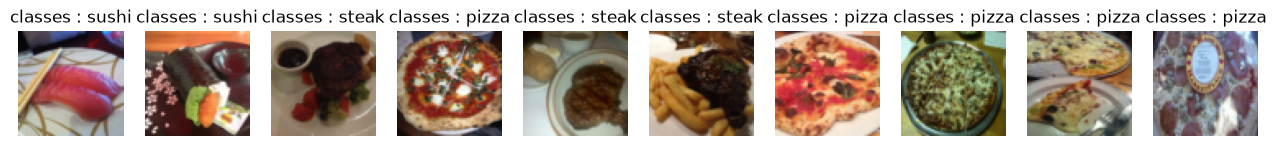

In [35]:
display_ramdom_images(train_data_custom,
                      class_name,
                      12,
                      seed=None)

In [36]:
from torch.utils.data import DataLoader
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=1,
                                     num_workers=0,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=1,shuffle=False)

train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x2a3aaeb9d10>,
 <torch.utils.data.dataloader.DataLoader at 0x2a3a98e6fd0>)

In [37]:
img_custom, label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

In [38]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

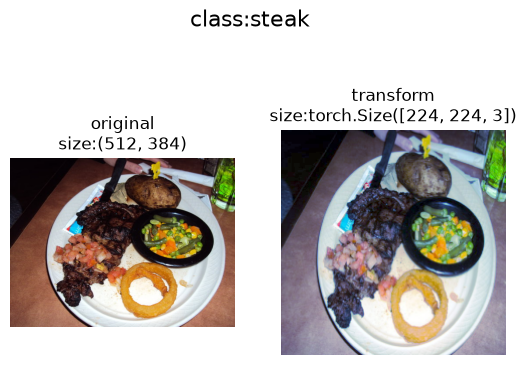

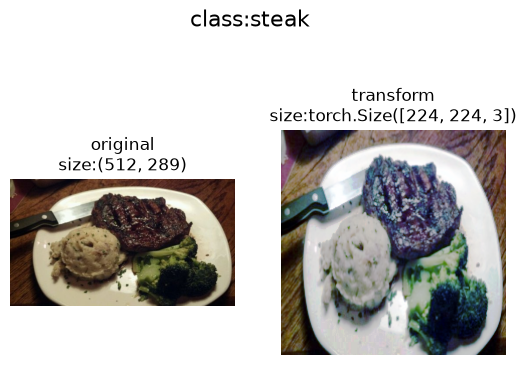

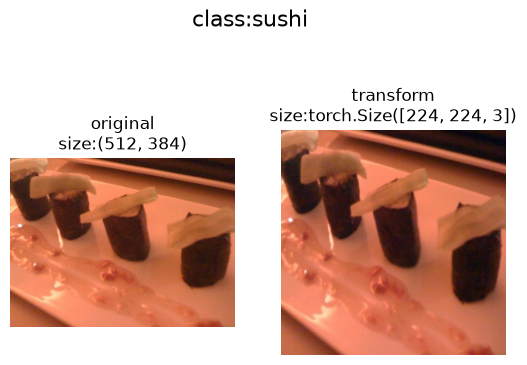

In [39]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

plot_transforms_image(
    image_path = image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)

In [40]:
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [41]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,transform=simple_transform)

import os 
from torch.utils.data import DataLoader

batch_size = 32
num_workers = os.cpu_count()
print(num_workers,batch_size)
train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=batch_size,
                                     num_workers=num_workers,
                                     shuffle=True,)

Test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=batch_size,
                                    shuffle=False,
                                    num_workers=num_workers)

train_dataloader_simple,Test_dataloader_simple

8 32


(<torch.utils.data.dataloader.DataLoader at 0x2a3a98e6520>,
 <torch.utils.data.dataloader.DataLoader at 0x2a3aaaa2f90>)

In [42]:
class TinyVGG(nn.Module):
    def __init__(self,input_shape:int,hidden_shape:int,output_shape:int) -> None:
        super().__init__()
        self.conv_block_1=nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_shape,
                      kernel_size=3,padding=2,stride=1),
        
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_shape,
                      out_channels=hidden_shape,kernel_size=3
                      ,stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_shape,hidden_shape,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_shape,hidden_shape,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_shape*16*16,output_shape)
        )
    def forward(self,x:torch.Tensor):
        x=self.conv_block_1(x)
        x=self.conv_block_2(x)
        x=self.classifier(x)
        return x

torch.manual_seed(42)
model_0 = TinyVGG(3,10,len(train_data.classes)).to(device)
model_0


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [43]:
img_batch ,label_batch = next(iter(train_dataloader_simple))
img_single ,label_single = img_batch[0].unsqueeze(dim=0),label_batch[0]
print(img_single.shape)

model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single)

# pred,torch.softmax(pred,dim=1),torch.argmax(pred,dim=1),label_single
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")
torch.argmax(pred,dim=1)


torch.Size([1, 3, 64, 64])
Output logits:
tensor([[0.0588, 0.0613, 0.0351]])

Output prediction probabilities:
tensor([[0.3357, 0.3365, 0.3278]])

Output prediction label:
tensor([1])

Actual label:
2


tensor([1])

In [44]:
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0,input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 33, 33]           --
│    └─Conv2d: 2-1                       [1, 10, 66, 66]           280
│    └─ReLU: 2-2                         [1, 10, 66, 66]           --
│    └─Conv2d: 2-3                       [1, 10, 66, 66]           910
│    └─ReLU: 2-4                         [1, 10, 66, 66]           --
│    └─MaxPool2d: 2-5                    [1, 10, 33, 33]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 33, 33]           910
│    └─ReLU: 2-7                         [1, 10, 33, 33]           --
│    └─Conv2d: 2-8                       [1, 10, 33, 33]           910
│    └─ReLU: 2-9                         [1, 10, 33, 33]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [45]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer):

    model.train()
    train_loss,train_acc=0,0

    for batch,(x,y) in enumerate(dataloader):
        x,y=x.to(device),y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc +=(y_pred_class == y ).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss,train_acc 

In [46]:
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module):

    model.eval()
    test_loss,test_acc=0,0
    with torch.inference_mode():
        for batch,(x,y) in enumerate(dataloader):
            x,y=x.to(device),y.to(device)
            test_pred_logits = model(x)

            loss=loss_fn(test_pred_logits,y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss /len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss,test_acc

In [50]:
from tqdm.auto import tqdm
def train(model:torch.nn.Module,
          train_dataloader:torch.utils.data.DataLoader,
          test_dataloader:torch.utils.data.DataLoader,
          optimizer:torch.optim.Optimizer,
          loss_fn:torch.nn.Module,
          epoch:int = 5):

    result={"train_loss":[],
            "test_loss":[],
            "train_acc":[],
            "test_acc":[]
            }
    

    for epoch in tqdm(range(epoch)):
        train_loss,train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)

        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        print(f"Epoch:{epoch+1} |"
              f"train_loss:{train_loss:.4f} |"
              f"train_acc:{train_acc:.4f} |"
              f"test_loss: {test_loss:.4f} |"
              f"test_acc:{test_acc:.4f}")

        result["train_loss"].append(train_loss.item() if isinstance(train_loss,torch.Tensor) else train_loss)
        result["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        result["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        result["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return result

In [51]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
num_epochs = 5
model_0 = TinyVGG(input_shape=3,
                  hidden_shape=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.001)

from timeit import default_timer as Timer
start_time=Timer()
model_0_result = train(model=model_0,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epoch=num_epochs)

end_time=Timer()
print(f"Total training time {end_time-start_time:.3f} s")

 20%|██        | 1/5 [00:17<01:09, 17.36s/it]

Epoch:1 |train_loss:1.2845 |train_acc:0.3008 |test_loss: 1.1978 |test_acc:0.2604


 40%|████      | 2/5 [00:29<00:43, 14.39s/it]

Epoch:2 |train_loss:1.1054 |train_acc:0.3047 |test_loss: 1.1285 |test_acc:0.2604


 60%|██████    | 3/5 [00:42<00:27, 13.76s/it]

Epoch:3 |train_loss:1.0921 |train_acc:0.3047 |test_loss: 1.0962 |test_acc:0.2604


 80%|████████  | 4/5 [00:56<00:13, 13.73s/it]

Epoch:4 |train_loss:1.0911 |train_acc:0.5273 |test_loss: 1.0796 |test_acc:0.5417


100%|██████████| 5/5 [01:10<00:00, 14.06s/it]

Epoch:5 |train_loss:1.0904 |train_acc:0.4023 |test_loss: 1.0683 |test_acc:0.5417
Total training time 70.319 s


In [53]:
model_0_result.keys()

dict_keys(['train_loss', 'test_loss', 'train_acc', 'test_acc'])

In [58]:
def plot_loss_curve(result:Dict[str,List[float]]):
    loss = result["train_loss"]
    test_loss = result["test_loss"]
    accuracy = result["train_acc"]
    test_accuracy = result["test_acc"]

    epochs = range(len(result["train_loss"]))

    plt.figure(figsize=(15,7))

    #plot loss
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,label="train loss")
    plt.plot(epochs,test_loss,label="test loss")
    plt.title("loss")
    plt.xlabel("epochs")
    plt.legend()

    #plot accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs,accuracy,label="train acc")
    plt.plot(epochs,test_accuracy,label="test acc")
    plt.title("accuracy")
    plt.xlabel("epochs")
    plt.legend()


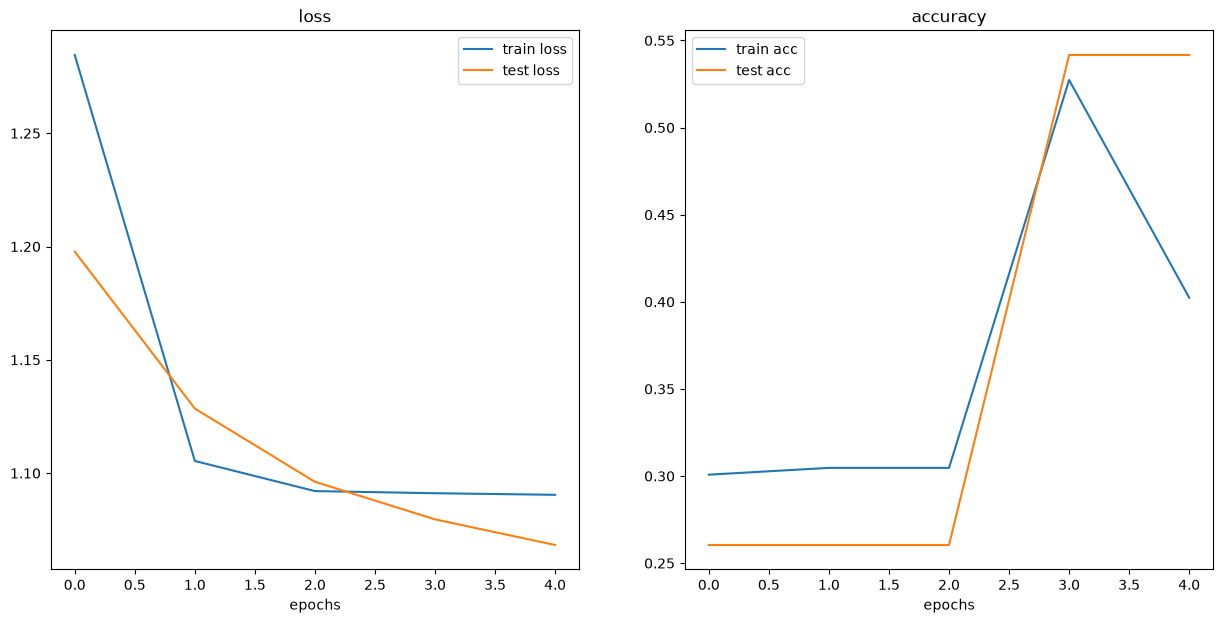

In [59]:
plot_loss_curve(model_0_result)